In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

In [2]:
path_hist = "D://Niharika Work//Climate_Project//CMIP6//IPSL_historical//"

### Load Historical Data

| Variable | Meaning                  |
| -------- | ------------------------ |
| `rsdt`   | Incoming solar radiation |
| `rsut`   | Reflected SW radiation   |
| `rlut`   | Outgoing LW radiation    |
| `rsutcs` | Clear-sky SW radiation   |
| `rlutcs` | Clear-sky LW radiation   |
| `tas`    | Surface temperature      |
| `clt`    | Total cloud fraction     |

In [3]:
rsdt_hist = xr.open_dataset(path_hist + "rsdt_Amon_IPSL-CM6A-LR_historical_r1i1p1f1_gr_185001-201412.nc", use_cftime=True)['rsdt']
rsut_hist = xr.open_dataset(path_hist + "rsut_Amon_IPSL-CM6A-LR_historical_r1i1p1f1_gr_185001-201412.nc", use_cftime=True)['rsut']
rlut_hist = xr.open_dataset(path_hist + "rlut_Amon_IPSL-CM6A-LR_historical_r1i1p1f1_gr_185001-201412.nc", use_cftime=True)['rlut']

rsutcs_hist = xr.open_dataset(path_hist + "rsutcs_Amon_IPSL-CM6A-LR_historical_r1i1p1f1_gr_185001-201412.nc", use_cftime=True)['rsutcs']
rlutcs_hist = xr.open_dataset(path_hist + "rlutcs_Amon_IPSL-CM6A-LR_historical_r1i1p1f1_gr_185001-201412.nc", use_cftime=True)['rlutcs']

tas_hist = xr.open_dataset(path_hist + "tas_Amon_IPSL-CM6A-LR_historical_r1i1p1f1_gr_185001-201412.nc")['tas']

C:\Users\shubh\AppData\Local\Temp\ipykernel_4092\3518661064.py:1: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  rsdt_hist = xr.open_dataset(path_hist + "rsdt_Amon_IPSL-CM6A-LR_historical_r1i1p1f1_gr_185001-201412.nc", use_cftime=True)['rsdt']
C:\Users\shubh\AppData\Local\Temp\ipykernel_4092\3518661064.py:2: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  rsut_hist = xr.open_dataset(path_hist + "rsut_Amon_IPSL-CM6A-LR_historical_r1i1p1f1_gr_185001-201412.nc", use_cftime=True)['rsut'

In [4]:
rsdt_hist = rsdt_hist.sel(time=slice("2001","2014"))
rsut_hist = rsut_hist.sel(time=slice("2001","2014"))
rlut_hist = rlut_hist.sel(time=slice("2001","2014"))

rsutcs_hist = rsutcs_hist.sel(time=slice("2001","2014"))
rlutcs_hist = rlutcs_hist.sel(time=slice("2001","2014"))

tas_hist = tas_hist.sel(time=slice("2001","2014"))

### Compute Historical TOA Net Radiation

In [5]:
toa_net_hist = rsdt_hist - rsut_hist - rlut_hist        # Net=rsdt−rsut−rlut

In [6]:
print(toa_net_hist)

<xarray.DataArray (time: 168, lat: 143, lon: 144)> Size: 14MB
array([[[ -39.82448 ,  -39.82448 ,  -39.82448 , ...,  -39.82448 ,
          -39.82448 ,  -39.82448 ],
        [ -41.48323 ,  -41.369263,  -41.273026, ...,  -41.665375,
          -41.596237,  -41.55252 ],
        [ -42.5428  ,  -42.337708,  -42.18744 , ...,  -42.826904,
          -42.647842,  -42.578613],
        ...,
        [-169.73476 , -169.80171 , -169.90924 , ..., -169.50427 ,
         -169.61963 , -169.7841  ],
        [-170.52275 , -170.67123 , -170.7472  , ..., -170.38979 ,
         -170.48189 , -170.50552 ],
        [-171.9942  , -171.9942  , -171.9942  , ..., -171.9942  ,
         -171.9942  , -171.9942  ]],

       [[ -72.552704,  -72.552704,  -72.552704, ...,  -72.552704,
          -72.552704,  -72.552704],
        [ -76.78987 ,  -76.744064,  -76.483734, ...,  -77.1376  ,
          -76.8752  ,  -76.986435],
        [ -78.01901 ,  -77.87268 ,  -77.66641 , ...,  -78.48201 ,
          -78.20116 ,  -78.12811 ],
...
 

### Compute Historical Cloud Radiative Effect

In [7]:
sw_cre_hist = rsutcs_hist - rsut_hist       # SWcre=rsutcs−rsut
lw_cre_hist = rlutcs_hist - rlut_hist       # LWcre=rlutcs−rlut

net_cre_hist = sw_cre_hist + lw_cre_hist

### Proper Area-Weighted Mean

In [8]:
# Grid cells shrink toward the poles, so we weight by cos(latitude).

weights = np.cos(np.deg2rad(net_cre_hist.lat))
weights.name = "weights"

###### Global mean CRE:

In [9]:
cre_hist_global = net_cre_hist.weighted(weights).mean(("lat","lon"))

In [10]:
print(cre_hist_global)

<xarray.DataArray (time: 168)> Size: 672B
array([-29.628025, -27.420973, -25.201918, -21.869833, -20.037275,
       -19.73287 , -20.438066, -23.139263, -24.019861, -25.957893,
       -26.58713 , -28.019554, -28.924814, -27.606005, -24.67238 ,
       -22.772552, -20.773191, -20.036118, -20.440676, -21.649632,
       -24.18107 , -24.762547, -26.333511, -28.563427, -29.59244 ,
       -27.597342, -24.62851 , -22.196795, -20.026642, -20.266191,
       -20.95217 , -22.067451, -23.826878, -24.954   , -26.410973,
       -28.476933, -28.30504 , -27.921944, -24.25434 , -21.86751 ,
       -19.271238, -18.902885, -19.819637, -22.335112, -23.640818,
       -24.480652, -26.027023, -26.660664, -28.207281, -26.684343,
       -24.47422 , -21.223564, -19.44495 , -19.511536, -20.949453,
       -22.394728, -24.562153, -26.023336, -26.778122, -27.852016,
       -28.20255 , -27.667942, -24.314934, -22.6017  , -20.93331 ,
       -19.993206, -20.53707 , -23.157887, -24.996895, -25.759417,
       -26.540249, -

###### Mean over time:

In [11]:
cre_hist_mean = cre_hist_global.mean("time")
print(cre_hist_mean.values)

-24.097895


Expected value: ≈ -20 W/m²

# classical climate feedback regression method

### 1 Compute Global Mean Temperature

In [12]:
# weights = np.cos(np.deg2rad(tas_hist.lat))
# weights.name = "weights"

T_global = tas_hist.weighted(weights).mean(("lat","lon"))

In [13]:
T_global

<xarray.DataArray 'tas' (time: 168)> Size: 672B
array([284.68262, 285.17017, 285.88437, 286.7207 , 287.64978, 288.45914,
       288.91965, 288.84702, 288.3034 , 286.99298, 285.9464 , 285.0268 ,
       284.62213, 284.99457, 285.7753 , 286.55267, 287.4206 , 288.2006 ,
       288.80057, 288.7504 , 288.1478 , 287.1463 , 285.96198, 285.11877,
       284.91968, 285.18185, 285.81403, 286.72894, 287.59497, 288.26434,
       288.89655, 288.9076 , 288.3371 , 287.19907, 285.91382, 284.88016,
       284.55948, 285.12698, 285.68607, 286.54077, 287.55295, 288.53775,
       289.07037, 288.81158, 288.16583, 287.19305, 286.07666, 285.301  ,
       284.97003, 285.38913, 286.07516, 287.00925, 287.91476, 288.69278,
       289.10022, 289.3493 , 288.53262, 287.4342 , 286.24673, 285.41037,
       285.16315, 285.6889 , 286.32446, 287.1746 , 288.01608, 288.69247,
       289.10776, 289.02557, 288.49588, 287.31363, 286.24622, 285.07895,
       284.9965 , 285.40573, 285.93402, 286.76666, 287.60184, 288.30505,
       288.90656, 288.94067, 288.18353, 286.98236, 285.97757, 285.2201 ,
       284.90244, 285.13715, 285.82843, 286.71304, 287.82095, 288.57898,
       289.01828, 288.99884, 288.5137 , 287.3091 , 286.10895, 285.32538,
       285.16864, 285.48416, 286.2428 , 287.05875, 288.063  , 288.94382,
       289.6094 , 289.44348, 288.83066, 287.76514, 286.84137, 285.803  ,
       285.63364, 285.82968, 286.6879 , 287.4577 , 288.1589 , 289.0539 ,
       289.40552, 289.4385 , 288.67108, 287.4945 , 286.30582, 285.71213,
       284.89297, 285.16776, 286.06323, 286.89078, 287.7897 , 288.60687,
       289.09915, 289.11835, 288.45554, 287.46616, 286.2619 , 285.5216 ,
       285.33936, 285.62924, 286.1843 , 287.27808, 288.13702, 288.9448 ,
       289.40723, 289.3445 , 288.65677, 287.47107, 286.3467 , 285.5327 ,
       285.24585, 285.53217, 286.2205 , 287.13687, 288.11774, 288.9671 ,
       289.40488, 289.23755, 288.74017, 287.63556, 286.3928 , 285.29642,
       284.9975 , 285.48383, 286.17755, 287.0236 , 287.80103, 288.64926,
       289.17334, 289.27695, 288.67776, 287.58102, 286.31015, 285.27417],
      dtype=float32)
Coordinates:
    height   float64 8B 2.0
  * time     (time) datetime64[ns] 1kB 2001-01-16T12:00:00 ... 2014-12-16T12:...

### 2 Compute Global Mean TOA Radiation

In [14]:
toa_net_hist = rsdt_hist - rsut_hist - rlut_hist        # R=rsdt−rsut−rlut

R_global = toa_net_hist.weighted(weights).mean(("lat","lon"))

In [15]:
R_global

<xarray.DataArray (time: 168)> Size: 672B
array([ 8.507762  ,  9.525717  ,  5.631683  ,  0.6474181 , -4.2906203 ,
       -6.1163626 , -5.5430775 , -4.7376714 , -1.27223   ,  0.41794947,
        2.6598134 ,  6.7194815 ,  9.8529415 ,  9.744638  ,  6.5777392 ,
        0.76326084, -3.975116  , -5.798899  , -5.406981  , -2.9988172 ,
       -1.5442586 ,  1.5806662 ,  3.2299945 ,  6.1087728 ,  8.914863  ,
        9.613859  ,  6.3433747 ,  1.0276222 , -3.734685  , -5.9984674 ,
       -5.96889   , -3.5214121 , -1.5162992 ,  0.7457962 ,  3.1277235 ,
        6.739062  , 10.542504  ,  8.778367  ,  7.0275245 ,  1.1364257 ,
       -2.9081311 , -5.127082  , -5.1156764 , -3.5106795 , -0.99762106,
        1.0468959 ,  2.7781627 ,  7.999996  , 10.2468405 ,  9.703311  ,
        6.200563  ,  1.2496636 , -3.0219886 , -5.283207  , -5.76834   ,
       -4.6835694 , -2.1932013 , -0.42207742,  1.9692401 ,  6.363709  ,
       10.467633  ,  8.4326935 ,  5.91331   ,  0.3489775 , -4.8467097 ,
       -6.3532724 , -5.8862376 , -4.7209945 , -2.525792  , -0.11106643,
        2.6218448 ,  6.7996416 ,  8.750851  ,  7.485851  ,  5.883805  ,
        0.09371031, -4.1264644 , -6.258729  , -6.2796297 , -3.2236094 ,
       -0.57876617,  0.4741852 ,  2.9742272 ,  7.2952304 , 10.360782  ,
       10.784674  ,  7.6145988 ,  1.7905035 , -2.6427653 , -4.4616513 ,
       -5.4456673 , -3.1272664 , -0.05263839,  1.2369214 ,  4.7197886 ,
        7.729808  ,  9.494589  , 11.137134  ,  7.3692884 ,  1.8572593 ,
       -4.1190596 , -5.62823   , -6.237833  , -4.7274594 , -1.1597294 ,
        0.7972406 ,  3.3820908 ,  6.8519382 ,  9.524004  ,  9.075901  ,
        4.9857435 , -0.13432324, -5.751369  , -7.2169313 , -6.4609547 ,
       -4.8371267 , -3.1327367 , -0.4424003 ,  2.439034  ,  6.5860896 ,
        9.192827  ,  9.331157  ,  6.393111  ,  0.98385185, -3.9169538 ,
       -5.135209  , -5.9046392 , -3.7583437 , -0.96051806,  1.9059451 ,
        4.7341375 ,  7.1632037 ,  9.648012  ,  9.350333  ,  6.210923  ,
        2.3905993 , -2.7472296 , -6.5203123 , -6.228132  , -4.120969  ,
       -2.67612   ,  1.1538997 ,  2.9555092 ,  7.301387  , 10.316364  ,
        8.980527  ,  7.1262755 ,  2.4046676 , -3.1113346 , -6.042323  ,
       -6.2024946 , -3.4962955 , -1.5874228 , -0.48979926,  2.7175257 ,
        7.292907  ,  8.976475  ,  8.870262  ,  6.7721686 ,  0.94798845,
       -3.504925  , -5.6959352 , -5.2357407 , -2.9865746 , -0.3788892 ,
        1.2099032 ,  3.226872  ,  7.9324117 ], dtype=float32)
Coordinates:
  * time     (time) object 1kB 2001-01-16 12:00:00 ... 2014-12-16 12:00:00

### 3 Compute Anomalies

In [16]:
# T_anom = T_global - T_global.mean("time")
# R_anom = R_global - R_global.mean("time")

T_anom = T_global.groupby("time.month") - T_global.groupby("time.month").mean()
R_anom = R_global.groupby("time.month") - R_global.groupby("time.month").mean()

In [17]:
# # Convert to NumPy Arrays
# # Regression needs numpy arrays.

T_anom_np = T_anom.values
R_anom_np = R_anom.values

In [18]:
print(R_anom.min(), R_anom.max())

<xarray.DataArray ()> Size: 4B
array(-1.9872723, dtype=float32) <xarray.DataArray ()> Size: 4B
array(1.7932463, dtype=float32)


In [19]:
T_anom_np

array([-0.32409668, -0.2027893 , -0.17977905, -0.2116394 , -0.18157959,
       -0.17636108, -0.21743774, -0.25946045, -0.17602539, -0.3630371 ,
       -0.26339722, -0.29470825, -0.38458252, -0.37838745, -0.28884888,
       -0.3796692 , -0.4107666 , -0.434906  , -0.33651733, -0.3560791 ,
       -0.33163452, -0.2097168 , -0.24783325, -0.20272827, -0.08703613,
       -0.19110107, -0.25012207, -0.20339966, -0.23638916, -0.3711548 ,
       -0.24053955, -0.19888306, -0.14233398, -0.1569519 , -0.29599   ,
       -0.4413452 , -0.4472351 , -0.24597168, -0.37808228, -0.39157104,
       -0.27841187, -0.0977478 , -0.06671143, -0.29489136, -0.31359863,
       -0.16296387, -0.1331482 , -0.02050781, -0.03668213,  0.01617432,
        0.01101685,  0.0769043 ,  0.08340454,  0.05728149, -0.03686523,
        0.24282837,  0.05319214,  0.07818604,  0.03692627,  0.08886719,
        0.1564331 ,  0.3159485 ,  0.26031494,  0.24224854,  0.1847229 ,
        0.05697632, -0.02932739, -0.0809021 ,  0.01644897, -0.04

In [20]:
R_anom_np

array([-1.1205559 ,  0.18182945, -0.80046797, -0.4602694 , -0.5265236 ,
       -0.2851758 ,  0.2915144 , -0.8483293 ,  0.19750023, -0.23234048,
       -0.44989848, -0.34363508,  0.22462368,  0.4007511 ,  0.1455884 ,
       -0.34442663, -0.21101928,  0.0322876 ,  0.42761087,  0.89052486,
       -0.07452834,  0.93037623,  0.12028265, -0.9543438 , -0.7134552 ,
        0.26997185, -0.08877611, -0.08006525,  0.02941179, -0.16728067,
       -0.13429832,  0.36792994, -0.04656899,  0.09550625,  0.01801157,
       -0.32405472,  0.9141865 , -0.5655203 ,  0.59537363,  0.02873826,
        0.8559656 ,  0.7041049 ,  0.71891546,  0.3786626 ,  0.4721092 ,
        0.3966059 , -0.33154917,  0.93687963,  0.61852264,  0.35942364,
       -0.23158789,  0.14197612,  0.7421081 ,  0.54797983,  0.06625175,
       -0.79422736, -0.72347105, -1.0723674 , -1.1404718 , -0.6994076 ,
        0.8393154 , -0.91119385, -0.5188408 , -0.75870997, -1.082613  ,
       -0.52208567, -0.05164576, -0.8316524 , -1.0560616 , -0.76

### 4 Compute Feedback Parameter

In [21]:
# lambda_feedback = np.polyfit(T_anom_np, R_anom_np, 1)[0]

# Before regression, remove NaN values:
mask = np.isfinite(T_anom_np) & np.isfinite(R_anom_np)

lambda_feedback = np.polyfit(
    T_anom_np[mask],
    R_anom_np[mask],
    1
)[0]

print("Feedback parameter λ =", lambda_feedback, "W m^-2 K^-1")

Feedback parameter λ = -0.5135236877118935 W m^-2 K^-1


Typical result:
λ ≈ -1 to -2 W m^-2 K^-1

Negative value → climate stabilizing feedback.

### 5 Plot Gregory Regression

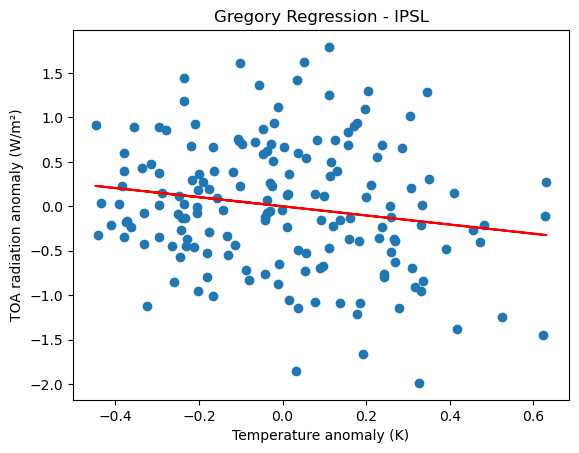

In [22]:
import matplotlib.pyplot as plt

plt.scatter(T_anom_np, R_anom_np)

fit = np.polyfit(T_anom_np, R_anom_np, 1)
plt.plot(T_anom_np, fit[0]*T_anom_np + fit[1], color="red")

plt.xlabel("Temperature anomaly (K)")
plt.ylabel("TOA radiation anomaly (W/m²)")
plt.title("Gregory Regression - IPSL")

plt.show()

| λ value | Meaning                      |
| ------- | ---------------------------- |
| λ < 0   | stabilizing climate feedback |
| λ > 0   | amplifying feedback          |

λ ≈ -1.0 W/m²/K

### Load Future Data (SSP585)

In [ ]:
path_future = "D://Niharika Work//Climate_Project//CMIP6//IPSL_ssp585//"

rsdt_future = xr.open_mfdataset(path_future + "rsdt*.nc", use_cftime=True)['rsdt']
rsut_future = xr.open_mfdataset(path_future + "rsut*.nc", use_cftime=True)['rsut']
rlut_future = xr.open_mfdataset(path_future + "rlut*.nc", use_cftime=True)['rlut']

rsutcs_future = xr.open_mfdataset(path_future + "rsutcs*.nc", use_cftime=True)['rsutcs']
rlutcs_future = xr.open_mfdataset(path_future + "rlutcs*.nc", use_cftime=True)['rlutcs']

tas_future = xr.open_mfdataset(path_future + "tas*.nc", use_cftime=True)['tas']

In [ ]:
rsdt_future = rsdt_future.sel(time=slice("2081","2100"))
rsut_future = rsut_future.sel(time=slice("2081","2100"))
rlut_future = rlut_future.sel(time=slice("2081","2100"))

rsutcs_future = rsutcs_future.sel(time=slice("2081","2100"))
rlutcs_future = rlutcs_future.sel(time=slice("2081","2100"))

tas_future = tas_future.sel(time=slice("2081","2100"))

### Compute Future CRE

In [ ]:
sw_cre_future = rsutcs_future - rsut_future
lw_cre_future = rlutcs_future - rlut_future

net_cre_future = sw_cre_future + lw_cre_future

### Compute Mean CRE

In [ ]:
cre_future_mean = net_cre_future.weighted(weights).mean(("lat","lon")).mean("time")

### Compute Temperature Change

In [ ]:
delta_T = tas_future.weighted(weights).mean(("lat","lon")).mean("time") \
         - tas_hist.weighted(weights).mean(("lat","lon")).mean("time")

## 1️⃣1️⃣ Compute Change in CRE

In [ ]:
delta_CRE = cre_future_mean - cre_hist_mean

In [ ]:
delta_CRE

## 1️⃣2️⃣ Cloud Feedback Parameter

$$
\lambda = \frac{\Delta CRE}{\Delta T}
$$

In [ ]:
lambda_cloud = delta_CRE / delta_T

print("Cloud feedback parameter:", lambda_cloud.values, "W/m²/K")

Typical value: ≈ 0.3 – 1.2 W/m²/K

## Spatial Feedback Map

In [ ]:
delta_cre_map = net_cre_future.mean("time") - net_cre_hist.mean("time")

lambda_map = delta_cre_map / delta_T

lambda_map.plot(cmap="RdBu_r", vmin=-2, vmax=2)
plt.title("Cloud Feedback Parameter")
plt.show()

# Compare CMIP6 model radiation with CERES satellite observations

In [23]:
path_ceres = "D://Niharika Work//Climate_Project//CERES_EBAF-TOA_Edition4.1-20260303_075023//"

ceres = xr.open_dataset(path_ceres + "CERES_EBAF-TOA_Edition4.1_200003-202203.nc")

print(ceres)

<xarray.Dataset> Size: 792MB
Dimensions:                        (lon: 360, lat: 180, ctime: 12, sc: 2,
                                    time: 265)
Coordinates:
  * lon                            (lon) float32 1kB 0.5 1.5 2.5 ... 358.5 359.5
  * lat                            (lat) float32 720B -89.5 -88.5 ... 88.5 89.5
  * ctime                          (ctime) int32 48B 1 2 3 4 5 6 7 8 9 10 11 12
  * time                           (time) datetime64[ns] 2kB 2000-03-15 ... 2...
Dimensions without coordinates: sc
Data variables: (12/67)
    climatology_bounds             (ctime, sc) int32 96B ...
    toa_sw_all_mon                 (time, lat, lon) float32 69MB ...
    toa_lw_all_mon                 (time, lat, lon) float32 69MB ...
    toa_net_all_mon                (time, lat, lon) float32 69MB ...
    toa_sw_clr_c_mon               (time, lat, lon) float32 69MB ...
    toa_lw_clr_c_mon               (time, lat, lon) float32 69MB ...
    ...                             ...
    gtoa_n

In [24]:
ceres = ceres.sel(time=slice("2001","2014"))

##### Extract Radiation Variables

In [25]:
ceres_sw = ceres['toa_sw_all_mon']
ceres_lw = ceres['toa_lw_all_mon']
ceres_net = ceres['toa_net_all_mon']

## Compute Global Mean (Area Weighted)

In [26]:
# CERES grid is 1°×1°, but we still weight properly.
weights_ceres = np.cos(np.deg2rad(ceres.lat))

ceres_net_global = ceres_net.weighted(weights_ceres).mean(("lat","lon"))

### Compare Model vs Satellite

In [27]:
toa_net_hist    # model result earlier

<xarray.DataArray (time: 168, lat: 143, lon: 144)> Size: 14MB
array([[[ -39.82448 ,  -39.82448 ,  -39.82448 , ...,  -39.82448 ,
          -39.82448 ,  -39.82448 ],
        [ -41.48323 ,  -41.369263,  -41.273026, ...,  -41.665375,
          -41.596237,  -41.55252 ],
        [ -42.5428  ,  -42.337708,  -42.18744 , ...,  -42.826904,
          -42.647842,  -42.578613],
        ...,
        [-169.73476 , -169.80171 , -169.90924 , ..., -169.50427 ,
         -169.61963 , -169.7841  ],
        [-170.52275 , -170.67123 , -170.7472  , ..., -170.38979 ,
         -170.48189 , -170.50552 ],
        [-171.9942  , -171.9942  , -171.9942  , ..., -171.9942  ,
         -171.9942  , -171.9942  ]],

       [[ -72.552704,  -72.552704,  -72.552704, ...,  -72.552704,
          -72.552704,  -72.552704],
        [ -76.78987 ,  -76.744064,  -76.483734, ...,  -77.1376  ,
          -76.8752  ,  -76.986435],
        [ -78.01901 ,  -77.87268 ,  -77.66641 , ...,  -78.48201 ,
          -78.20116 ,  -78.12811 ],
...
        [-186.0441  , -185.95207 , -186.1114  , ..., -186.27382 ,
         -186.3336  , -186.23938 ],
        [-187.74321 , -187.80078 , -187.8064  , ..., -187.51894 ,
         -187.54059 , -187.47682 ],
        [-188.13663 , -188.13663 , -188.13663 , ..., -188.13663 ,
         -188.13663 , -188.13663 ]],

       [[ -31.323395,  -31.323395,  -31.323395, ...,  -31.323395,
          -31.323395,  -31.323395],
        [ -32.8058  ,  -32.77501 ,  -32.588776, ...,  -33.05986 ,
          -32.962402,  -32.915283],
        [ -33.154816,  -32.934906,  -32.804092, ...,  -33.592316,
          -33.451004,  -33.27736 ],
        ...,
        [-185.69691 , -185.7322  , -185.59233 , ..., -186.79315 ,
         -186.64162 , -186.09251 ],
        [-185.64984 , -185.98479 , -185.81165 , ..., -185.58102 ,
         -185.52898 , -185.56284 ],
        [-184.2737  , -184.2737  , -184.2737  , ..., -184.2737  ,
         -184.2737  , -184.2737  ]]], shape=(168, 143, 144), dtype=float32)
Coordinates:
  * lat      (lat) float32 572B -90.0 -88.73 -87.46 -86.2 ... 87.46 88.73 90.0
  * lon      (lon) float32 576B 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * time     (time) object 1kB 2001-01-16 12:00:00 ... 2014-12-16 12:00:00

##### Compute model global mean:

In [28]:
model_net_global = toa_net_hist.weighted(weights).mean(("lat","lon"))

In [29]:
model_net_global        

<xarray.DataArray (time: 168)> Size: 672B
array([ 8.507762  ,  9.525717  ,  5.631683  ,  0.6474181 , -4.2906203 ,
       -6.1163626 , -5.5430775 , -4.7376714 , -1.27223   ,  0.41794947,
        2.6598134 ,  6.7194815 ,  9.8529415 ,  9.744638  ,  6.5777392 ,
        0.76326084, -3.975116  , -5.798899  , -5.406981  , -2.9988172 ,
       -1.5442586 ,  1.5806662 ,  3.2299945 ,  6.1087728 ,  8.914863  ,
        9.613859  ,  6.3433747 ,  1.0276222 , -3.734685  , -5.9984674 ,
       -5.96889   , -3.5214121 , -1.5162992 ,  0.7457962 ,  3.1277235 ,
        6.739062  , 10.542504  ,  8.778367  ,  7.0275245 ,  1.1364257 ,
       -2.9081311 , -5.127082  , -5.1156764 , -3.5106795 , -0.99762106,
        1.0468959 ,  2.7781627 ,  7.999996  , 10.2468405 ,  9.703311  ,
        6.200563  ,  1.2496636 , -3.0219886 , -5.283207  , -5.76834   ,
       -4.6835694 , -2.1932013 , -0.42207742,  1.9692401 ,  6.363709  ,
       10.467633  ,  8.4326935 ,  5.91331   ,  0.3489775 , -4.8467097 ,
       -6.3532724 , -5.8862376 , -4.7209945 , -2.525792  , -0.11106643,
        2.6218448 ,  6.7996416 ,  8.750851  ,  7.485851  ,  5.883805  ,
        0.09371031, -4.1264644 , -6.258729  , -6.2796297 , -3.2236094 ,
       -0.57876617,  0.4741852 ,  2.9742272 ,  7.2952304 , 10.360782  ,
       10.784674  ,  7.6145988 ,  1.7905035 , -2.6427653 , -4.4616513 ,
       -5.4456673 , -3.1272664 , -0.05263839,  1.2369214 ,  4.7197886 ,
        7.729808  ,  9.494589  , 11.137134  ,  7.3692884 ,  1.8572593 ,
       -4.1190596 , -5.62823   , -6.237833  , -4.7274594 , -1.1597294 ,
        0.7972406 ,  3.3820908 ,  6.8519382 ,  9.524004  ,  9.075901  ,
        4.9857435 , -0.13432324, -5.751369  , -7.2169313 , -6.4609547 ,
       -4.8371267 , -3.1327367 , -0.4424003 ,  2.439034  ,  6.5860896 ,
        9.192827  ,  9.331157  ,  6.393111  ,  0.98385185, -3.9169538 ,
       -5.135209  , -5.9046392 , -3.7583437 , -0.96051806,  1.9059451 ,
        4.7341375 ,  7.1632037 ,  9.648012  ,  9.350333  ,  6.210923  ,
        2.3905993 , -2.7472296 , -6.5203123 , -6.228132  , -4.120969  ,
       -2.67612   ,  1.1538997 ,  2.9555092 ,  7.301387  , 10.316364  ,
        8.980527  ,  7.1262755 ,  2.4046676 , -3.1113346 , -6.042323  ,
       -6.2024946 , -3.4962955 , -1.5874228 , -0.48979926,  2.7175257 ,
        7.292907  ,  8.976475  ,  8.870262  ,  6.7721686 ,  0.94798845,
       -3.504925  , -5.6959352 , -5.2357407 , -2.9865746 , -0.3788892 ,
        1.2099032 ,  3.226872  ,  7.9324117 ], dtype=float32)
Coordinates:
  * time     (time) object 1kB 2001-01-16 12:00:00 ... 2014-12-16 12:00:00

In [30]:
model_net_global["time"] = model_net_global.indexes["time"].to_datetimeindex()

C:\Users\shubh\AppData\Local\Temp\ipykernel_4092\806988269.py:1: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeIndex. This warning can be silenced by explicitly passing the `time_unit` keyword argument.
  model_net_global["time"] = model_net_global.indexes["time"].to_datetimeindex()


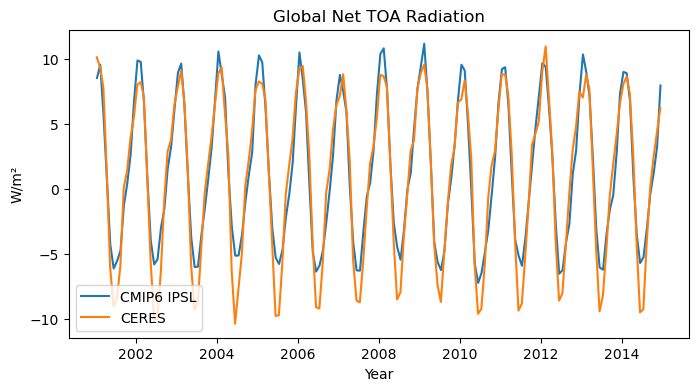

In [35]:
plt.figure(figsize=(8,4))

model_net_global.plot(label="CMIP6 IPSL")
ceres_net_global.plot(label="CERES")

plt.xlabel("Year")

plt.legend()
plt.title("Global Net TOA Radiation")
plt.ylabel("W/m²")

plt.show()

## Compute Model Bias

In [32]:
bias = model_net_global.mean("time") - ceres_net_global.mean("time")    # Bias=Model−Observation

print("Radiation bias:", bias.values, "W/m²")

Radiation bias: 0.5025252 W/m²


Typical CMIP6 bias: ±1–3 W/m²

### Spatial Bias Map

In [34]:
import xesmf as xe

regridder = xe.Regridder(toa_net_hist, ceres_net, "bilinear")

model_regrid = regridder(toa_net_hist.mean("time"))

ModuleNotFoundError: No module named 'ESMF'

In [ ]:
bias_map = model_regrid - ceres_net.mean("time")

bias_map.plot(cmap="RdBu_r", vmin=-20, vmax=20)
plt.title("TOA Radiation Bias (Model - CERES)")
plt.show()